# Imaging Tutorial with the Sparse Modeling Technique

This notebook is a tutorial of synthesis imaging based on the sparse modeling technique using PRIISM. 
**PRIISM** is an imaging tool for radio interferometry based on the sparse modeling technique ([PRIISM](https://github.com/tnakazato/priism): Python Module for Radio Interferometry Imaging with Sparse Modeling). 

In this tutorial, we try end-to-end synthesis imaging for ALMA interferometry data using `runner` module with parameter file. For interactive processing using `priism.alma`, please see `tutorial_twhya.ipynb`.

## Setup and Initialize PRIISM

Before you start this tutorial, you should install PRIISM and packages that PRIISM depends on (casatools, casatasks, etc.). Please see README.md on how to install PRIISM. In addition, you need to install `astropy` because this tutorial uses `astropy` to display final image.

There are two fundamental submodules, `priism.core` and `priism.alma`, which are mainly for interactive use. For batch mode, we have `priism.runner` submodule. Here, we demonstrate how to use `runner` submodule as well as show the format of parameter file for `runner`.

First, we import PRIISM to show the version information. This is not mandatory in terms of processing.

In [1]:
import priism.alma
print(f'PRIISM version {priism.__version__}')

PRIISM version 0.16.2


And we make matplotlib figures to be displayed in the notebook.

In [2]:
%matplotlib inline

## ALMA Data : HL Tau

Sample data for the tutorial is the protoplanetary disk "**HL Tau**" observed at Band 6 with long baselines of ALMA 12m array as part of [science verification](https://almascience.nao.ac.jp/alma-data/science-verification). The calibration information can be obtained from [CASA Guide](https://casaguides.nrao.edu/index.php?title=ALMA2014_LBC_SVDATA#HL_Tau_-_Protoplanetary_Disk), and the data can be downloaded from the link below: 

https://almascience.nao.ac.jp/almadata/sciver/HLTauBand6/HLTau_Band6_CalibratedData.tgz

After you download the data, you should extract the MS from the file. You may run the following cell to obtain the dataset.

In [3]:
%%bash

# download if necessary
[ -e HLTau_Band6_CalibratedData.tgz ] || wget -nv https://almascience.nao.ac.jp/almadata/sciver/HLTauBand6/HLTau_Band6_CalibratedData.tgz

# extract data from tar-ball
[ -e HLTau_Band6_CalibratedData ] || tar xf HLTau_Band6_CalibratedData.tgz

## Data Preparation

Since we downloaded calibrated data, input MS is already available at `HLTau_Band6_CalibratedData/HLTau_B6cont.calavg`. Here we just define some variables for convenience. Also, we run `listobs` to get data summary.

In [4]:
import os
from casatasks import listobs

data_dir = 'HLTau_Band6_CalibratedData'
vis = 'HLTau_B6cont.calavg'
listfile = 'HLTau_B6cont.calavg.listobs'
imagename = 'hltau_b6cont_spw0.fits'
    
listobs(vis=f'{data_dir}/{vis}', listfile=listfile, verbose=True, overwrite=True)

# extract spw setup from data summary
os.system(f'grep -E "^Spectral Windows:" -A 5 {listfile}')

Spectral Windows:  (4 unique spectral windows and 1 unique polarization setups)
  SpwID  Name                           #Chans   Frame   Ch0(MHz)  ChanWid(kHz)  TotBW(kHz) CtrFreq(MHz) BBC Num  Corrs  
  0      ALMA_RB_06#BB_1#SW-01#FULL_RES      4   TOPO  224750.000   -500000.000   2000000.0 224000.0000        1  XX  YY
  1      ALMA_RB_06#BB_2#SW-01#FULL_RES      4   TOPO  226750.000   -500000.000   2000000.0 226000.0000        2  XX  YY
  2      ALMA_RB_06#BB_3#SW-01#FULL_RES      4   TOPO  239250.000    500000.000   2000000.0 240000.0000        3  XX  YY
  3      ALMA_RB_06#BB_4#SW-01#FULL_RES      4   TOPO  241250.000    500000.000   2000000.0 242000.0000        4  XX  YY


....10....20....30....40....50....60....70....80....90....100%


0

## End-to-end Processing using a Parameter File

Imaging and cross-validation can be processed using parameters stored in a parameter file. PRIISM has `runner` submodule for this purpose. For reading the parameter file, `loadParam` is used. And also, the used parameters can be stored by `saveParam`. You can use `runner` module interactively, too. In the interactive use case, `runner` submodule saves processing parameters in a parameter file of *.param. (The parameters in cross-validations are automatically stored, such as "cvname.param".) You can manually make the parameter file and apply that for imaging and cross-validation as well.

For example, you can perform imaging or cross-validation using the parameter file "`test.param`" as follows,

```
from priism import runner
hh=runner.Session.loadParam('test.param')
hh.run(overwrite=True)
```

or

```
from priism import runner
hh=runner.Session.loadParam('test.param')
hh.crossValidation(overwrite=True)
```

The sample of the parameter file for the classical cross-validation is given below. We create the parameter file first. Then we perform end-to-end imaging using `runner` submodule.

First, create the param file.

In [5]:
config = f'''vis:            {data_dir}/{vis}
field:          0
spw:            0
ch:             0~3
datacolumn:     data
imname:         {imagename}
imsize:         [800, 800]
cell:           ['0.005arcsec']
nchan:          1
start:          0
width:          4
cvname:         hltau_b6cont_spw0.cv
solver:         pymfista_nufft
l1:             1000000000.0
ltsv:           1000000000.0
maxiter:        100
numFold:        4
imagePolicy:    full
l1List:         [1000.0, 10000.0, 100000.0, 1000000.0]
ltsvList:       [100000000.0, 1000000000.0, 10000000000.0, 100000000000.0]
optimizer:      classical
bayesopt_maxiter:       15
'''

with open('test.param', 'w') as f:
    f.write(config)

Contents of the param file is as follows:

In [6]:
with open('test.param', 'r') as f:
    print(f.read())

vis:            HLTau_Band6_CalibratedData/HLTau_B6cont.calavg
field:          0
spw:            0
ch:             0~3
datacolumn:     data
imname:         hltau_b6cont_spw0.fits
imsize:         [800, 800]
cell:           ['0.005arcsec']
nchan:          1
start:          0
width:          4
cvname:         hltau_b6cont_spw0.cv
solver:         pymfista_nufft
l1:             1000000000.0
ltsv:           1000000000.0
maxiter:        100
numFold:        4
imagePolicy:    full
l1List:         [1000.0, 10000.0, 100000.0, 1000000.0]
ltsvList:       [100000000.0, 1000000000.0, 10000000000.0, 100000000000.0]
optimizer:      classical
bayesopt_maxiter:       15



Then, feed `test.param` to `runner` submodule.

In [7]:
%%timeit -n 1 -r 1

from priism import runner
hh=runner.Session.loadParam('test.param')
hh.run(overwrite=True)

2026/08/28 07:54:53	INFO	loadParam	## Reading parameter file : test.param
2026/08/28 07:54:53	INFO	__init__	#############################
2026/08/28 07:54:53	INFO	__init__	(runner.Session): vis = HLTau_Band6_CalibratedData/HLTau_B6cont.calavg
2026/08/28 07:54:53	INFO	_setWorker	###### Start PRIISM
2026/08/28 07:54:53	WARNING	_warn_refocus	***WARN*** refocusing is disabled even if distance to the source is known.


read 8000 visibility chunks

2026/08/28 07:56:52	INFO	readvis	read 8064 visibility chunks
2026/08/28 07:56:52	INFO	readvis	DONE reading visibility chunks


read 8064 visibility chunks


2026/08/28 07:56:54	INFO	run	## Image name : hltau_b6cont_spw0.fits
2026/08/28 08:03:50	INFO	_show_result	
2026/08/28 08:03:50	INFO	_show_result	
2026/08/28 08:03:50	INFO	_show_result	Size of the problem:
2026/08/28 08:03:50	INFO	_show_result	 size of input vector:  3464751
2026/08/28 08:03:50	INFO	_show_result	 size of output vector: 640000
2026/08/28 08:03:50	INFO	_show_result	size of image:          800 x 800
2026/08/28 08:03:50	INFO	_show_result	
2026/08/28 08:03:50	INFO	_show_result	Problem Setting:
2026/08/28 08:03:50	INFO	_show_result	 x is a nonnegative vector.

2026/08/28 08:03:50	INFO	_show_result	 Lambda_l1: 1.000000e+09
2026/08/28 08:03:50	INFO	_show_result	 Lambda_tsv: 1.000000e+09
2026/08/28 08:03:50	INFO	_show_result	 MAXITER: 100
2026/08/28 08:03:50	INFO	_show_result	
2026/08/28 08:03:50	INFO	_show_result	Results:
2026/08/28 08:03:50	INFO	_show_result	 # of iterations:       100
2026/08/28 08:03:50	INFO	_show_result	 cost:                  1.218087e+10
2026/08/28 08:03:

## Display Final Image

The created image is displayed here using the `matplotlib` module. Please note that intensity unit of resulting image will be **Jy/pixel** if input visibility data is correctly calibrated.

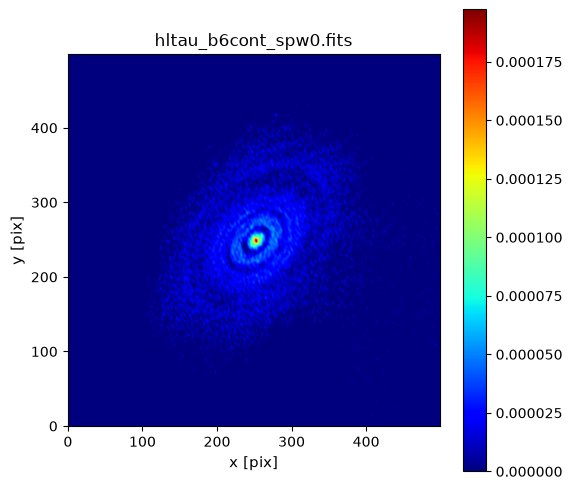

In [8]:
from astropy.io import fits
from matplotlib import pyplot as plt

pixs=800; imwd=500; exwd = (pixs-imwd) // 2
ff,aa=plt.subplots(1,1, figsize=(6,6))
im=aa.imshow(fits.getdata(imagename)[0,0,exwd+40:((pixs-1)-exwd)+40,exwd:((pixs-1)-exwd)], 
             origin='lower', cmap='jet')
#             vmin=0, vmax=0.0005, origin='lower', cmap='jet')
cbar=plt.colorbar(im, ax=aa)
aa.set_title(imagename)
aa.set_xlabel("x [pix]",size=11)
aa.set_ylabel("y [pix]",size=11)
plt.savefig(imagename.replace('fits','png'), bbox_inches="tight", pad_inches=0.05)
plt.show()

## Acknowledgements

This tutorial makes use of the following ALMA data: ADS/JAO.ALMA#2011.0.00015.SV. ALMA is a partnership of ESO (representing its member states), NSF (USA) and NINS (Japan), together with NRC (Canada) and NSC and ASIAA (Taiwan), and KASI (Republic of Korea), in cooperation with the Republic of Chile. The Joint ALMA Observatory is operated by ESO, AUI/NRAO and NAOJ.